<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_10_Time_Series_Forecasting_Using_Weather_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Installing Required Libraries
!pip install statsmodels pmdarima autots --quiet

In [4]:
# Uploading the Dataset from computer
from google.colab import files
uploaded = files.upload()

Saving daily-minimum-temperatures-in-me.csv to daily-minimum-temperatures-in-me (1).csv


In [5]:
# Extracting / Loading the Dataset
import pandas as pd

# Loading the dataset
df = pd.read_csv("daily-minimum-temperatures-in-me.csv", on_bad_lines='skip')

# Renaming column for easier use
df.columns = ["Date", "Temp"]

# Converting Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Setting the Date as index
df.set_index("Date", inplace=True)

# Displaying first rows
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [6]:
# Inspecting hte Dataset Structure
# Dataset information
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (3650, 1)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Temp    3650 non-null   object
dtypes: object(1)
memory usage: 57.0+ KB


,Temp
count,3650
unique,230
top,10.0
freq,51


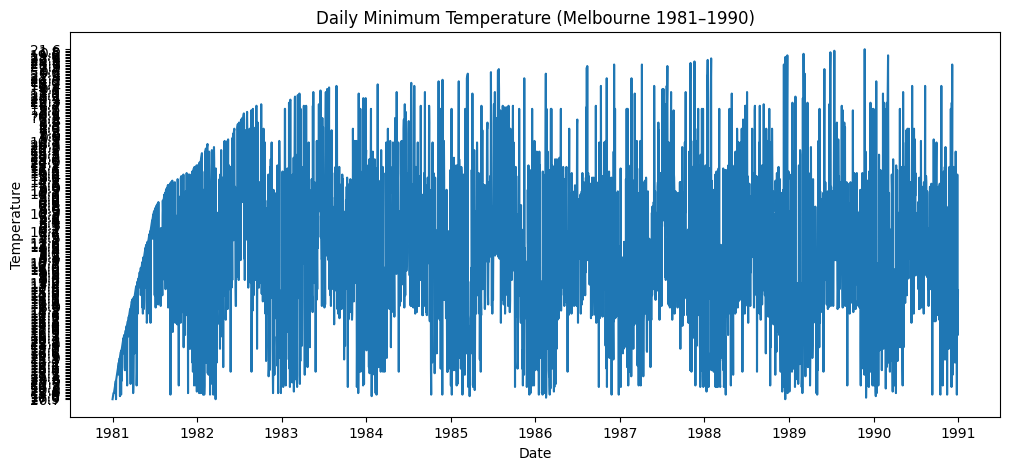

'Helps identify trend and seasonality\n\nWeather data usually shows strong yearly seasonality'

In [7]:
# Visualizing Time Series
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Temp"])
plt.title("Daily Minimum Temperature (Melbourne 1981–1990)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

"""Helps identify trend and seasonality

Weather data usually shows strong yearly seasonality"""

In [8]:
# Converting temperature column to numeric
df["Temp"] = pd.to_numeric(df["Temp"], errors="coerce")

# Removing the rows with invalid or missing values
df = df.dropna()

# Verifying cleaning
print("Missing values:", df.isna().sum())
df.head()

Missing values: Temp    0
dtype: int64


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [9]:
# Stationarity Test (ADF Test)
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Temp"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is NOT Stationary")

"""p < 0.05 -> stationary

If not stationary -> apply differencing"""

ADF Statistic: -4.444652847181708
p-value: 0.00024723724658534517
Series is Stationary


'p < 0.05 -> stationary\n\nIf not stationary -> apply differencing'

In [10]:
print(df["Temp"].dtype)

float64


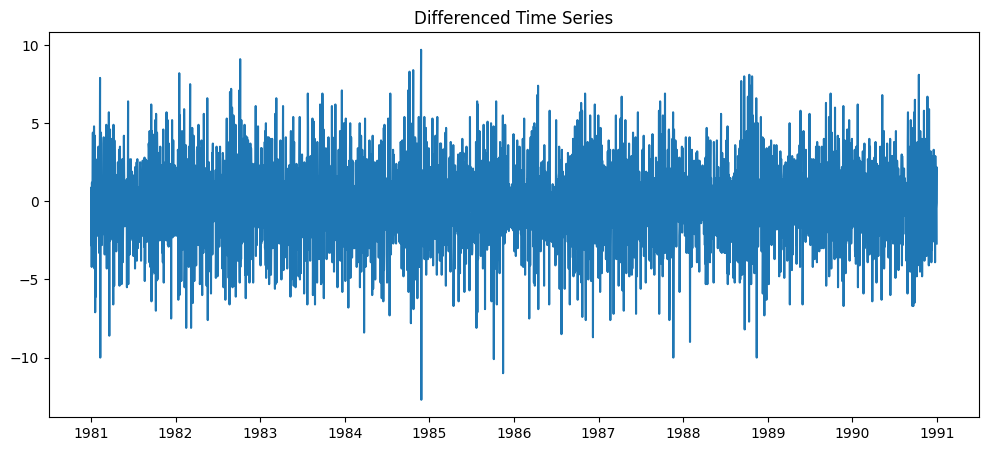

In [12]:
# Differencing
df_diff = df.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(df_diff)
plt.title("Differenced Time Series")
plt.show()

<Figure size 1200x500 with 0 Axes>

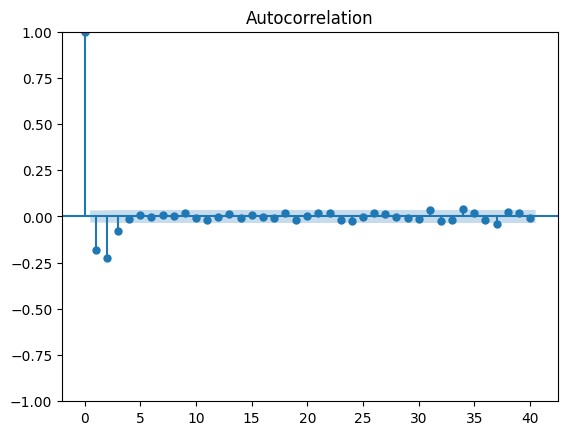

<Figure size 1200x500 with 0 Axes>

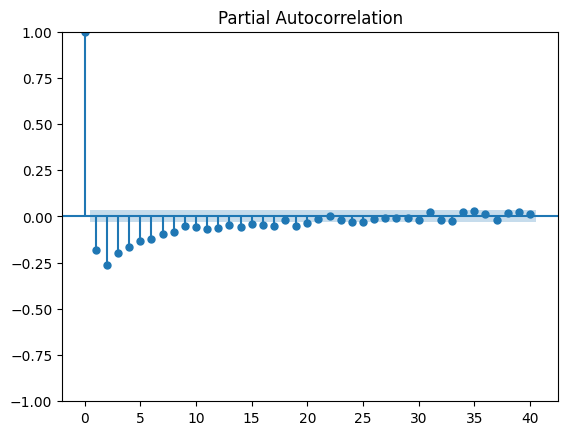

'ACF → q parameter\n\nPACF → p parameter\n\nd = number of differences applied\n\nExample values often used for this dataset: p = 2 - d = 1 - q =2'

In [13]:
# ACF and PACF Plots - Parameter Identification
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plot_acf(df_diff, lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df_diff, lags=40)
plt.show()

"""ACF → q parameter

PACF → p parameter

d = number of differences applied

Example values often used for this dataset: p = 2 - d = 1 - q =2"""

In [14]:
# ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

# Train model
model_arima = ARIMA(df["Temp"], order=(2,1,2))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 3647
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -8378.010
Date:                Sun, 08 Mar 2026   AIC                          16766.019
Time:                        22:59:15   BIC                          16797.026
Sample:                             0   HQIC                         16777.062
                               - 3647                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4653      0.133      3.492      0.000       0.204       0.726
ar.L2         -0.1166      0.066     -1.755      0.079      -0.247       0.014
ma.L1         -0.8711      0.135     -6.455      0.0

In [15]:
# Forecast Next 30 Days (ARIMA)
forecast_arima = model_arima_fit.forecast(steps=30)

forecast_arima

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
3647,13.094791
3648,13.505773
3649,13.685948
3650,13.721865
3651,13.717571
3652,13.711385
3653,13.709008
3654,13.708623
3655,13.708721
3656,13.708811


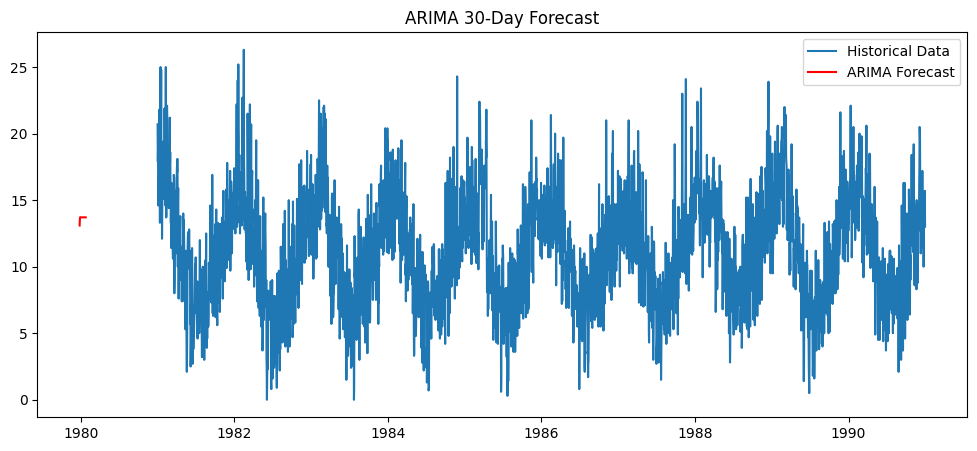

In [16]:
# Plotting the ARIMA Forecast
plt.figure(figsize=(12,5))

plt.plot(df["Temp"], label="Historical Data")
plt.plot(forecast_arima, label="ARIMA Forecast", color="red")

plt.legend()
plt.title("ARIMA 30-Day Forecast")
plt.show()

In [17]:
# SARIMAX Model Seasonality
# Weather data has yearly seasonality - 365 days
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax = SARIMAX(df["Temp"],
                        order=(2,1,2),
                        seasonal_order=(1,1,1,365))

model_sarimax_fit = model_sarimax.fit()

print(model_sarimax_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


KeyboardInterrupt: 

In [ ]:
# SARIMAX Forecast
forecast_sarimax = model_sarimax_fit.forecast(steps=30)

forecast_sarimax

In [ ]:
# Plotting the SARIMAX Forecast
plt.figure(figsize=(12,5))

plt.plot(df["Temp"], label="Historical Data")
plt.plot(forecast_sarimax, label="SARIMAX Forecast", color="green")

plt.legend()
plt.title("SARIMAX 30-Day Forecast")
plt.show()

In [ ]:
# AutoML Forecasting Using AutoTS
from autots import AutoTS

# Reset index for AutoTS
data = df.reset_index()

model = AutoTS(
    forecast_length=30,
    frequency='D',
    ensemble='simple'
)

model = model.fit(data, date_col='Date', value_col='Temp')

prediction = model.predict()

forecast_autots = prediction.forecast

forecast_autots.head()

In [ ]:
# Plotting the AutoML Forecast
plt.figure(figsize=(12,5))

plt.plot(df["Temp"], label="Historical Data")
plt.plot(forecast_autots, label="AutoTS Forecast", color="orange")

plt.legend()
plt.title("AutoML (AutoTS) Forecast")
plt.show()

In [ ]:
# Model Evaluation (MAPE)
from sklearn.metrics import mean_absolute_percentage_error

train = df[:-30]
test = df[-30:]

In [ ]:
# ARIMA MAPE
model = ARIMA(train["Temp"], order=(2,1,2)).fit()
pred = model.forecast(steps=30)

mape_arima = mean_absolute_percentage_error(test["Temp"], pred)

print("ARIMA MAPE:", mape_arima)

In [ ]:
# SARIMAX MAPE
model = SARIMAX(train["Temp"],
                order=(2,1,2),
                seasonal_order=(1,1,1,365)).fit()

pred = model.forecast(steps=30)

mape_sarimax = mean_absolute_percentage_error(test["Temp"], pred)

print("SARIMAX MAPE:", mape_sarimax)

In [ ]:
# Results Comparison
print("Model Comparison (MAPE)")

print("ARIMA:", mape_arima)
print("SARIMAX:", mape_sarimax)